In [1]:
import pandas as pd

# 1. Cleaned Dataset Load Karo
df = pd.read_csv('crm_sales_extended_mar2026.csv')

# 2. Dimensions Check Karo (Rows, Columns)
print("=== DATASET DIMENSIONS ===")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

# 3. Data Types Aur Columns Info
print("\n=== DATA TYPES & SUMMARY ===")
print(df.info())

# 4. Target Variable Breakdown (is_won)
print("\n=== TARGET VARIABLE BREAKDOWN (is_won) ===")
print(df['is_won'].value_counts(dropna=False))

# 5. Baseline Overall Win Rate Calculation
win_rate = df['is_won'].mean() * 100
print(f"\nOverall Win Rate: {win_rate:.2f}%")

=== DATASET DIMENSIONS ===
Total Rows: 25300
Total Columns: 20

=== DATA TYPES & SUMMARY ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25300 entries, 0 to 25299
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   opportunity_id      25300 non-null  object 
 1   sales_agent         25300 non-null  object 
 2   product             25300 non-null  object 
 3   account             25300 non-null  object 
 4   deal_stage          25300 non-null  object 
 5   engage_date         24800 non-null  object 
 6   close_date          19259 non-null  object 
 7   close_value         19259 non-null  float64
 8   sector              25300 non-null  object 
 9   revenue             25300 non-null  float64
 10  employees           25300 non-null  float64
 11  office_location     25300 non-null  object 
 12  manager             25300 non-null  object 
 13  regional_office     25300 non-null  object 
 14  close_val

=== CORRELATION WITH IS_WON ===
is_won                1.000000
close_value_capped    0.549728
sales_cycle_days      0.126055
employees             0.061735
revenue_capped        0.058173
Name: is_won, dtype: float64

============= WIN RATE BY SECTOR =============
                sector  total_deals  won_deals  win_rate
4            marketing         1937    1171.95     60.50
8             software         2169    1293.62     59.64
10  telecommunications         1456     853.69     58.63
2        entertainment         1258     722.61     57.44
9           technology         3384    1937.26     57.25
7             services         1102     627.88     56.98
6               retail         3919    2230.83     56.92
3              finance         2046    1157.25     56.56
5              medical         3047    1697.53     55.71
1           employment          849     456.37     53.75
0    Unassigned Sector         4133       0.00      0.00

============= WIN RATE BY PRODUCT =============
   

/tmp/ipykernel_655/4250969436.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sector_df[sector_df['sector'] != 'Unassigned Sector'], y='sector', x='win_rate', palette='Blues_r')
/tmp/ipykernel_655/4250969436.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_df, y='product', x='win_rate', palette='Greens_r')
/tmp/ipykernel_655/4250969436.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg_df, x='regional_office', y='win_rate', palette='Purples_r')


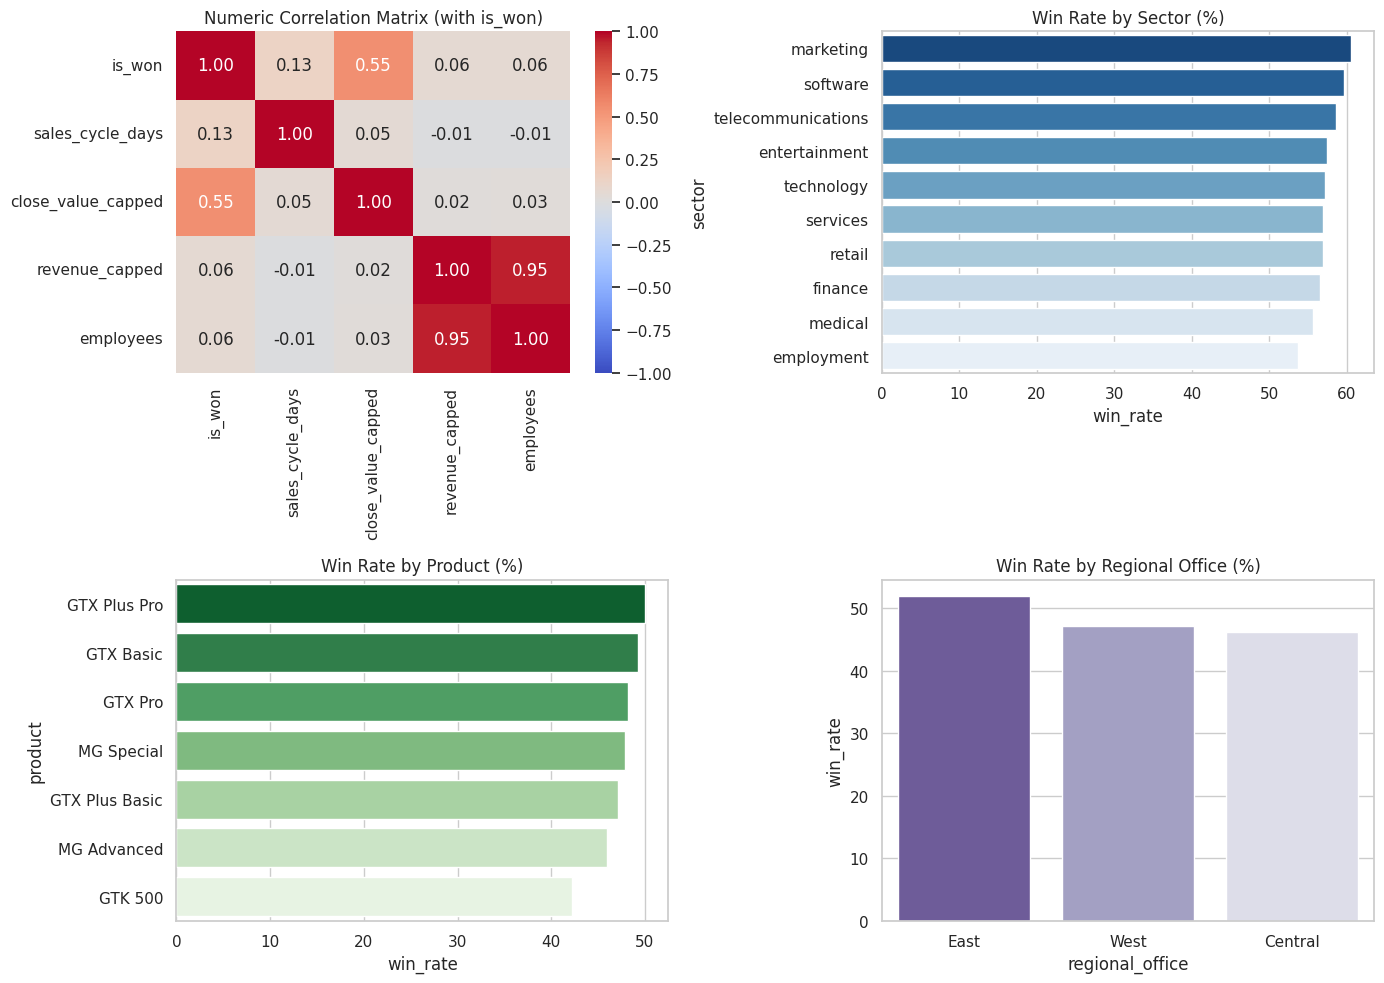

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
df = pd.read_csv('crm_sales_extended_mar2026.csv')

# 2. Correlation Analysis (Numeric Features vs is_won)
numeric_cols = ['is_won', 'sales_cycle_days', 'close_value_capped', 'revenue_capped', 'employees']
corr_matrix = df[numeric_cols].corr()

print("=== CORRELATION WITH IS_WON ===")
print(corr_matrix['is_won'].sort_values(ascending=False))

# Helper Function to calculate Win Rate
def get_win_rate(df, col_name):
    return df.groupby(col_name).agg(
        total_deals=('is_won', 'count'),
        won_deals=('is_won', 'sum'),
        win_rate=('is_won', lambda x: round(x.mean() * 100, 2))
    ).reset_index().sort_values(by='win_rate', ascending=False)

# 3. Categorical Win Rate Breakdowns
print("\n============= WIN RATE BY SECTOR =============")
print(get_win_rate(df, 'sector'))

print("\n============= WIN RATE BY PRODUCT =============")
print(get_win_rate(df, 'product'))

print("\n=============  WIN RATE BY REGIONAL OFFICE =============")
print(get_win_rate(df, 'regional_office'))

print("\n=============  WIN RATE BY MANAGER =============")
print(get_win_rate(df, 'manager'))

# 4. Visualizations (Correlation Heatmap & Barplots)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 10))

# Heatmap
plt.subplot(2, 2, 1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Numeric Correlation Matrix (with is_won)')

# Sector Win Rate (Excluding Unassigned)
plt.subplot(2, 2, 2)
sector_df = get_win_rate(df, 'sector')
sns.barplot(data=sector_df[sector_df['sector'] != 'Unassigned Sector'], y='sector', x='win_rate', palette='Blues_r')
plt.title('Win Rate by Sector (%)')

# Product Win Rate
plt.subplot(2, 2, 3)
product_df = get_win_rate(df, 'product')
sns.barplot(data=product_df, y='product', x='win_rate', palette='Greens_r')
plt.title('Win Rate by Product (%)')

# Regional Office Win Rate
plt.subplot(2, 2, 4)
reg_df = get_win_rate(df, 'regional_office')
sns.barplot(data=reg_df, x='regional_office', y='win_rate', palette='Purples_r')
plt.title('Win Rate by Regional Office (%)')

plt.tight_layout()
plt.show()

=== SECTOR-WISE SALES CYCLE DAYS STATS ===
                sector  Count   Mean  Median    Std   Min     Max
3              finance   1847  50.52   52.00  41.61  0.90  151.46
8             software   2035  49.69   45.56  41.96  0.90  146.57
6               retail   3549  49.31   49.00  41.48  0.90  147.54
2        entertainment   1128  48.34   43.63  42.07  0.90  145.09
10  telecommunications   1318  47.76   41.82  41.42  0.91  143.45
1           employment    779  47.54   45.00  40.39  0.90  138.00
5              medical   2745  47.20   42.00  41.39  0.90  150.66
4            marketing   1786  46.98   45.00  40.74  0.90  147.30
9           technology   3078  46.74   42.00  40.97  0.90  143.03
7             services    994  45.72   35.97  40.67  0.90  140.67
0    Unassigned Sector      0    NaN     NaN    NaN   NaN     NaN

=== PRODUCT-WISE SALES CYCLE DAYS STATS ===
          product  Count   Mean  Median    Std   Min     Max
0         GTK 500     74  58.32   63.51  42.22  0.96  137.2

/tmp/ipykernel_655/2008438371.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_655/2008438371.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


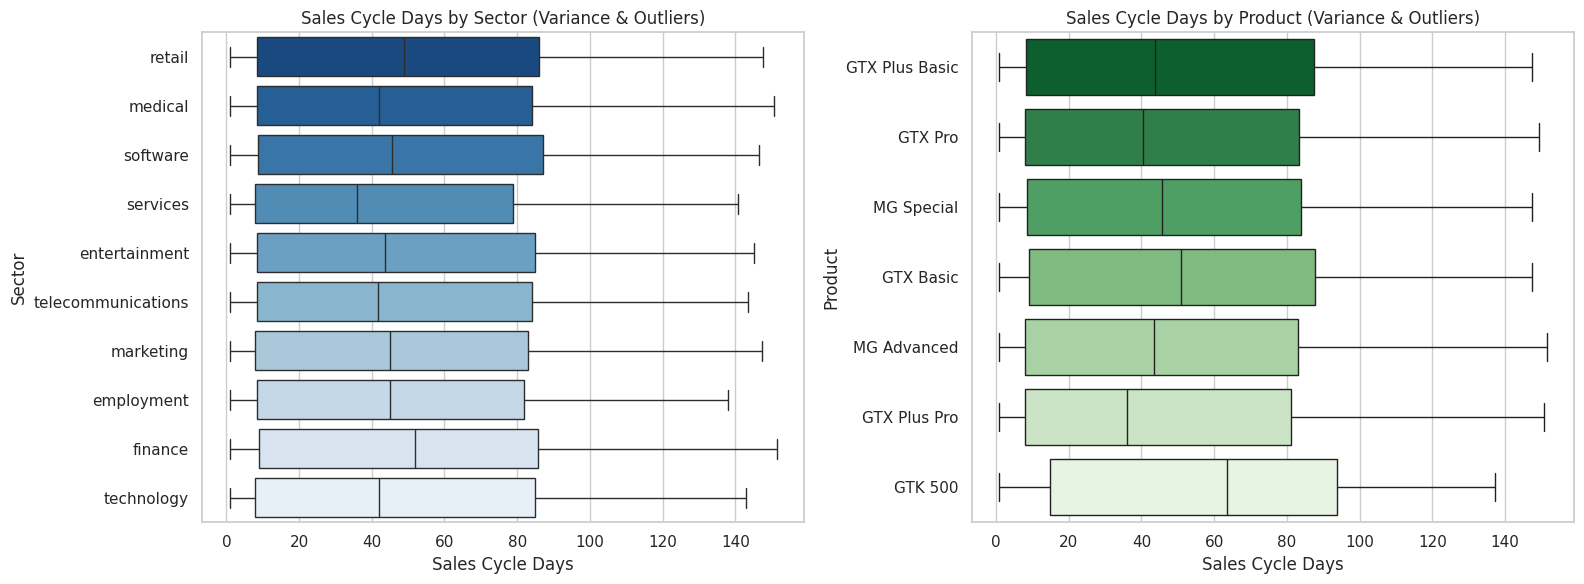

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
df = pd.read_csv('crm_sales_extended_mar2026.csv')

# 2. Descriptive Statistics Function
def cycle_days_stats(df, group_col):
    stats = df.groupby(group_col)['sales_cycle_days'].agg(
        Count='count',
        Mean='mean',
        Median='median',
        Std='std',
        Min='min',
        Max='max'
    ).reset_index().sort_values(by='Mean', ascending=False)

    stats[['Mean', 'Median', 'Std']] = stats[['Mean', 'Median', 'Std']].round(2)
    return stats

# Sector and Product Statistics
print("=== SECTOR-WISE SALES CYCLE DAYS STATS ===")
print(cycle_days_stats(df, 'sector'))

print("\n=== PRODUCT-WISE SALES CYCLE DAYS STATS ===")
print(cycle_days_stats(df, 'product'))

# 3. Boxplots for Deal Cycle Variance & Outliers
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sector Boxplot
sns.boxplot(
    data=df[df['sector'] != 'Unassigned Sector'],
    y='sector',
    x='sales_cycle_days',
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Sales Cycle Days by Sector (Variance & Outliers)')
axes[0].set_xlabel('Sales Cycle Days')
axes[0].set_ylabel('Sector')

# Product Boxplot
sns.boxplot(
    data=df,
    y='product',
    x='sales_cycle_days',
    ax=axes[1],
    palette='Greens_r'
)
axes[1].set_title('Sales Cycle Days by Product (Variance & Outliers)')
axes[1].set_xlabel('Sales Cycle Days')
axes[1].set_ylabel('Product')

plt.tight_layout()
plt.show()

=== DESCRIPTIVE STATISTICS ===
       close_value_capped  revenue_capped  employees
count            19259.00        25300.00   25300.00
mean              1439.61         2343.85    5322.22
std               1996.65         2400.99    6277.60
min                  0.00            4.09       8.10
25%                  0.00          741.11    1501.00
50%                469.00         1698.20    3492.00
75%               3204.69         2818.38    6394.16
max               6822.59        12864.24   37666.55


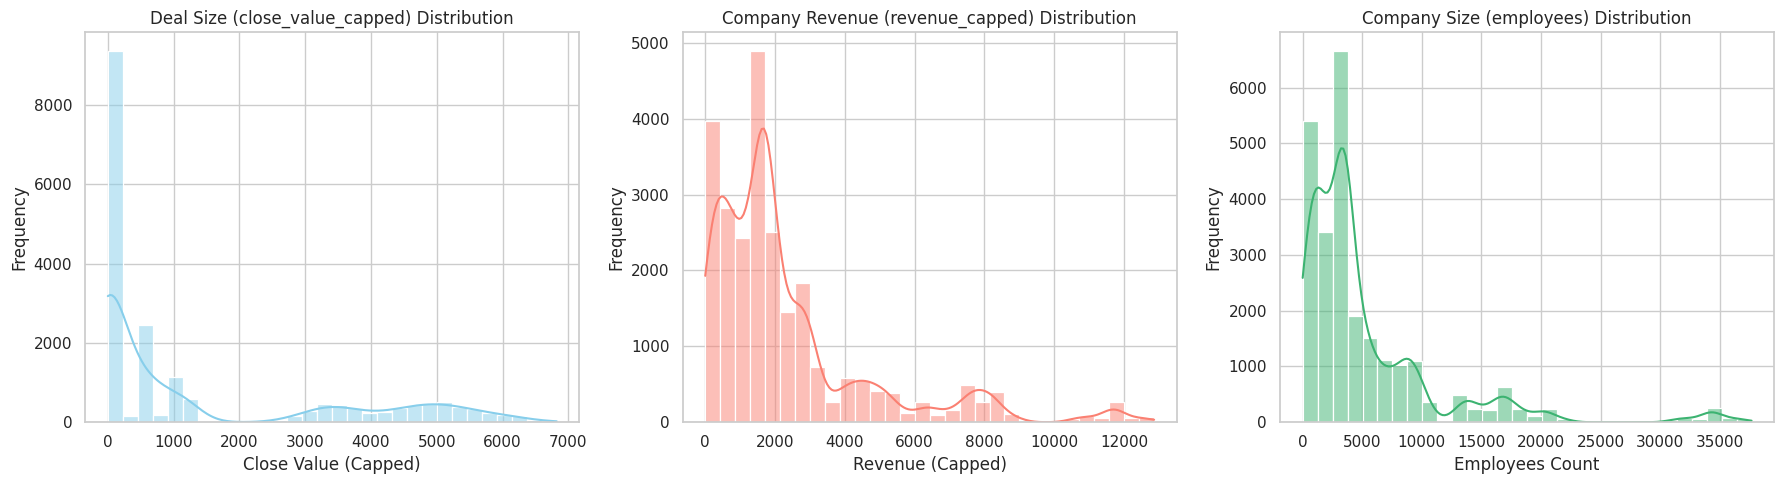

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Cleaned Dataset
df = pd.read_csv('crm_sales_extended_mar2026.csv')

# 2. Descriptive Statistics
cols = ['close_value_capped', 'revenue_capped', 'employees']
print("=== DESCRIPTIVE STATISTICS ===")
print(df[cols].describe().round(2))

# 3. Visualizations: Histograms + KDE Plots
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Close Value Capped
sns.histplot(df['close_value_capped'].dropna(), kde=True, ax=axes[0], color='skyblue', bins=30)
axes[0].set_title('Deal Size (close_value_capped) Distribution')
axes[0].set_xlabel('Close Value (Capped)')
axes[0].set_ylabel('Frequency')

# Plot 2: Revenue Capped
sns.histplot(df['revenue_capped'].dropna(), kde=True, ax=axes[1], color='salmon', bins=30)
axes[1].set_title('Company Revenue (revenue_capped) Distribution')
axes[1].set_xlabel('Revenue (Capped)')
axes[1].set_ylabel('Frequency')

# Plot 3: Employees
sns.histplot(df['employees'].dropna(), kde=True, ax=axes[2], color='mediumseagreen', bins=30)
axes[2].set_title('Company Size (employees) Distribution')
axes[2].set_xlabel('Employees Count')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()